<a href="https://colab.research.google.com/github/Vishnu-Shakya/Deep-Learning/blob/main/1_Logistic_reg/HR_Logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [63]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [64]:
df = pd.read_csv('/content/drive/MyDrive/data/HR_comma_sep.csv')

df["salary"] = df["salary"].map({
    "low":1,
    "medium":2,
    "high":3
})
df = df.drop(columns=["index","sales"], errors="ignore")
df.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,salary
0,0.38,0.53,2,157,3,0,1,0,1
1,0.80,0.86,5,262,6,0,1,0,2
2,0.11,0.88,7,272,4,0,1,0,2
3,0.72,0.87,5,223,5,0,1,0,1
4,0.37,0.52,2,159,3,0,1,0,1


In [65]:
corr = df.corr(numeric_only=True)

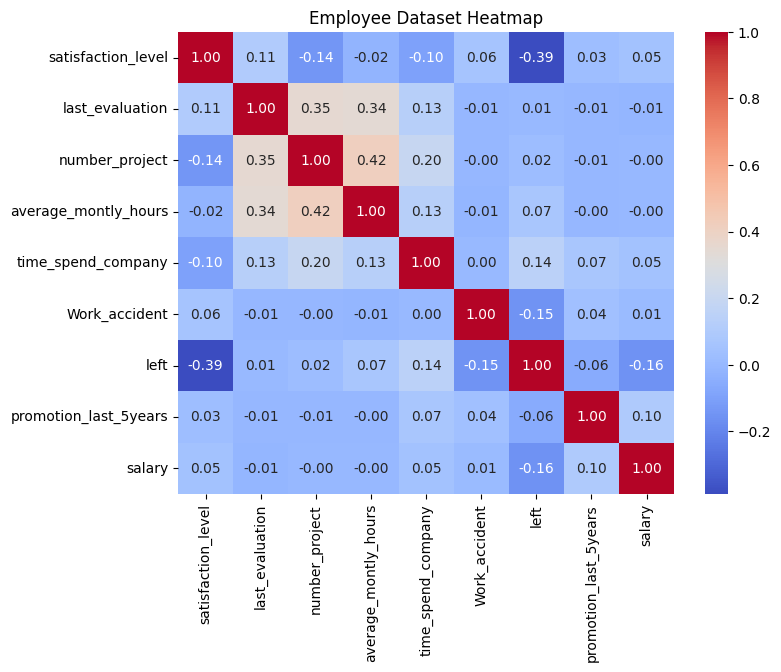

In [51]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Employee Dataset Heatmap")
plt.show()

In [66]:
X = df.drop("left", axis=1)   # features
y = df["left"]                # target

In [67]:
X

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary
0,0.38,0.53,2,157,3,0,0,1
1,0.80,0.86,5,262,6,0,0,2
2,0.11,0.88,7,272,4,0,0,2
3,0.72,0.87,5,223,5,0,0,1
4,0.37,0.52,2,159,3,0,0,1
...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,0,1
14995,0.37,0.48,2,160,3,0,0,1
14996,0.37,0.53,2,143,3,0,0,1
14997,0.11,0.96,6,280,4,0,0,1


In [68]:
from sklearn.model_selection import train_test_split

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.8)


In [70]:
X_test

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary
2981,0.93,0.48,3,147,3,0,0,1
2061,0.82,0.65,4,148,3,0,0,3
4181,0.19,0.93,3,110,4,0,0,2
10084,0.63,0.41,3,180,5,1,0,2
4520,0.70,0.44,2,131,2,0,0,1
...,...,...,...,...,...,...,...,...
5355,0.14,0.96,3,196,5,1,0,2
9075,0.93,0.57,2,205,4,1,0,2
10289,0.90,0.55,3,195,3,0,0,2
7565,0.95,0.77,3,184,4,0,0,2


In [80]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC()
}

In [72]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [81]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [84]:
from sklearn.metrics import accuracy_score, classification_report

summary = []

for name, model in models.items():

    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    report = classification_report(y_test, y_pred, output_dict=True)

    summary.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall (Left)": report["1"]["recall"],
        "F1 (Left)": report["1"]["f1-score"]
    })

import pandas as pd
print(pd.DataFrame(summary).sort_values(by="Accuracy", ascending=False))

                 Model  Accuracy  Recall (Left)  F1 (Left)
2        Random Forest  0.991667       0.973793   0.982603
3    Gradient Boosting  0.978333       0.943448   0.954641
1        Decision Tree  0.977667       0.939310   0.953114
5                  SVM  0.969000       0.922759   0.935010
4                  KNN  0.964333       0.929655   0.926460
0  Logistic Regression  0.787667       0.344828   0.439754
